# Datenverständnis — PM2.5 in Beijing

**Capstone-Projekt · CRISP-DM Phase 2 (Data Understanding)**  
Bettina Gertjerenken · Kai Steffen

In diesem Notebook schauen wir uns die Rohdaten genau an: **Was ist da, was fehlt, und wie sehen die Werte aus?** 
Ziel ist ein sauberer Überblick, bevor wir in Phase 3 (Datenaufbereitung) und Phase 4 (Modellierung mit Prophet, Chronos & PatchTST) weiterarbeiten.

> **Datensatz:** *Beijing Multi-Site Air-Quality Data* (PRSA), 12 Messstationen, stündliche Messungen von März 2013 bis Februar 2017.

In [1]:
import sys
print("Umgebung:", sys.executable)   # muss ...\envs\ts-tutorial\... enthalten

# die wichtigsten Pakete prüfen
import importlib.metadata as m

pakete = ["prophet", "chronos-forecasting", "transformers",
          "datasets", "gluonts", "torch", "pandas", "matplotlib"]

for p in pakete:
    try:
        print(f"✓ {p:20s} {m.version(p)}")
    except m.PackageNotFoundError:
        print(f"✗ {p:20s} FEHLT")

Umgebung: C:\Users\kaiws\anaconda3\envs\ts-tutorial\python.exe
✓ prophet              1.3.0
✓ chronos-forecasting  2.3.0
✓ transformers         5.12.1
✓ datasets             1.1.1
✓ gluonts              0.16.3
✓ torch                2.5.1+cpu
✓ pandas               2.3.3
✓ matplotlib           3.10.9


## 1. Bibliotheken und Daten laden

Wir laden alle 12 CSV-Dateien (eine je Station) und fügen sie zu **einer** großen Tabelle zusammen. 
Aus den Spalten `year, month, day, hour` bauen wir eine echte Zeitstempel-Spalte `datetime` — die brauchen wir später für die Zeitreihen.

In [2]:
import glob, os
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

# Ordner mit den 12 CSV-Dateien (relativ zum Notebook)
DATA_DIR = Path("../data/PRSA_Data_20130301-20170228")
if not DATA_DIR.exists():
    DATA_DIR = Path("capstone projekt/data/PRSA_Data_20130301-20170228")

files = sorted(glob.glob(str(DATA_DIR / "*.csv")))
frames = [pd.read_csv(f) for f in files]        # jede Station einzeln einlesen
df = pd.concat(frames, ignore_index=True)        # zu einer Tabelle zusammenfügen

# echte Zeitstempel-Spalte bauen
df["datetime"] = pd.to_datetime(df[["year", "month", "day", "hour"]])

pollutants = ["PM2.5", "PM10", "SO2", "NO2", "CO", "O3"]
meteo = ["TEMP", "PRES", "DEWP", "RAIN", "WSPM"]

print(f"Gesamt-Datensatz: {df.shape[0]:,} Zeilen x {df.shape[1]} Spalten")
print(f"Stationen: {df['station'].nunique()}  |  Zeilen je Station: {len(frames[0]):,}")
print(f"Zeitraum: {df['datetime'].min()}  bis  {df['datetime'].max()}")
print("Frequenz: stuendlich")

Gesamt-Datensatz: 420,768 Zeilen x 19 Spalten
Stationen: 12  |  Zeilen je Station: 35,064
Zeitraum: 2013-03-01 00:00:00  bis  2017-02-28 23:00:00
Frequenz: stuendlich


## 2. Struktur: Welche Spalten haben wir?

Der Datensatz enthält pro Zeile **eine Stunde an einer Station**. Die Spalten sind:

| Spalte | Bedeutung |
|---|---|
| `PM2.5`, `PM10` | Feinstaub (µg/m³) — **PM2.5 ist unsere Zielgröße** |
| `SO2`, `NO2`, `CO`, `O3` | weitere Luftschadstoffe |
| `TEMP`, `PRES`, `DEWP` | Temperatur, Luftdruck, Taupunkt |
| `RAIN`, `WSPM` | Regen (mm), Windgeschwindigkeit (m/s) |
| `wd` | Windrichtung (16 Kategorien, z. B. `NW`) |
| `station` | Name der Messstation |
| `year`–`hour` | Zeitangaben |

Ein Blick auf die ersten Zeilen:

In [3]:
df[['datetime'] + pollutants + ['TEMP','wd','WSPM','station']].head(6)

,datetime,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,wd,WSPM,station
0,2013-03-01 00:00:00,4.0,4.0,4.0,7.0,300.0,77.0,-0.7,NNW,4.4,Aotizhongxin
1,2013-03-01 01:00:00,8.0,8.0,4.0,7.0,300.0,77.0,-1.1,N,4.7,Aotizhongxin
2,2013-03-01 02:00:00,7.0,7.0,5.0,10.0,300.0,73.0,-1.1,NNW,5.6,Aotizhongxin
3,2013-03-01 03:00:00,6.0,6.0,11.0,11.0,300.0,72.0,-1.4,NW,3.1,Aotizhongxin
4,2013-03-01 04:00:00,3.0,3.0,12.0,12.0,300.0,72.0,-2.0,N,2.0,Aotizhongxin
5,2013-03-01 05:00:00,5.0,5.0,18.0,18.0,400.0,66.0,-2.2,N,3.7,Aotizhongxin


## 3. Fehlende Werte — *was fehlt?*

Jetzt die wichtigste Frage der Datenexploration: **Wo fehlen Werte (NaN)?** 
Wir zählen die fehlenden Werte je Spalte, absolut und in Prozent.

In [4]:
miss = df.isna().sum()
pct = (miss / len(df) * 100).round(2)
tabelle = pd.DataFrame({"fehlend": miss, "Prozent": pct})
tabelle = tabelle[tabelle["fehlend"] > 0].sort_values("fehlend", ascending=False)
print(tabelle)

       fehlend  Prozent
CO       20701     4.92
O3       13277     3.16
NO2      12116     2.88
SO2       9021     2.14
PM2.5     8739     2.08
PM10      6449     1.53
wd        1822     0.43
DEWP       403     0.10
TEMP       398     0.09
PRES       393     0.09
RAIN       390     0.09
WSPM       318     0.08


Die Schadstoffe haben deutlich mehr Lücken als die Wetterdaten. 
**CO** fehlt am häufigsten (~5 %), die Wetterspalten fast gar nicht (< 0,1 %). 
Unsere Zielgröße **PM2.5 fehlt zu ~2 %** — das ist wenig und gut handhabbar.

Als Balkendiagramm:

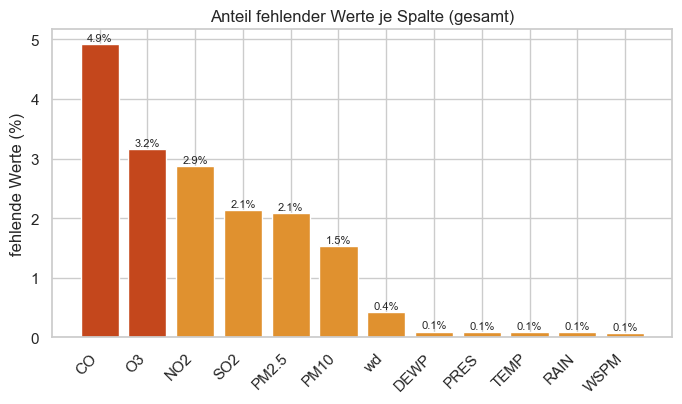

In [5]:
miss_pct = pct[pct > 0].sort_values(ascending=False)
plt.figure(figsize=(8, 4))
farben = ["#C4471C" if v > 3 else "#E0912F" for v in miss_pct.values]
bars = plt.bar(miss_pct.index, miss_pct.values, color=farben)
plt.ylabel("fehlende Werte (%)")
plt.title("Anteil fehlender Werte je Spalte (gesamt)")
for b, v in zip(bars, miss_pct.values):
    plt.text(b.get_x()+b.get_width()/2, v+0.05, f"{v:.1f}%", ha="center", fontsize=8)
plt.xticks(rotation=45, ha="right"); plt.show()

### Fehlen die PM2.5-Werte gleichmäßig — oder geballt?

Für die Modellierung ist entscheidend, **ob Lücken zufällig verstreut sind oder als lange Blöcke** auftreten (z. B. Sensorausfall über Wochen). 
Die Heatmap zeigt je Station und Monat den Anteil fehlender PM2.5-Werte. Dunkle Felder = viele Lücken.

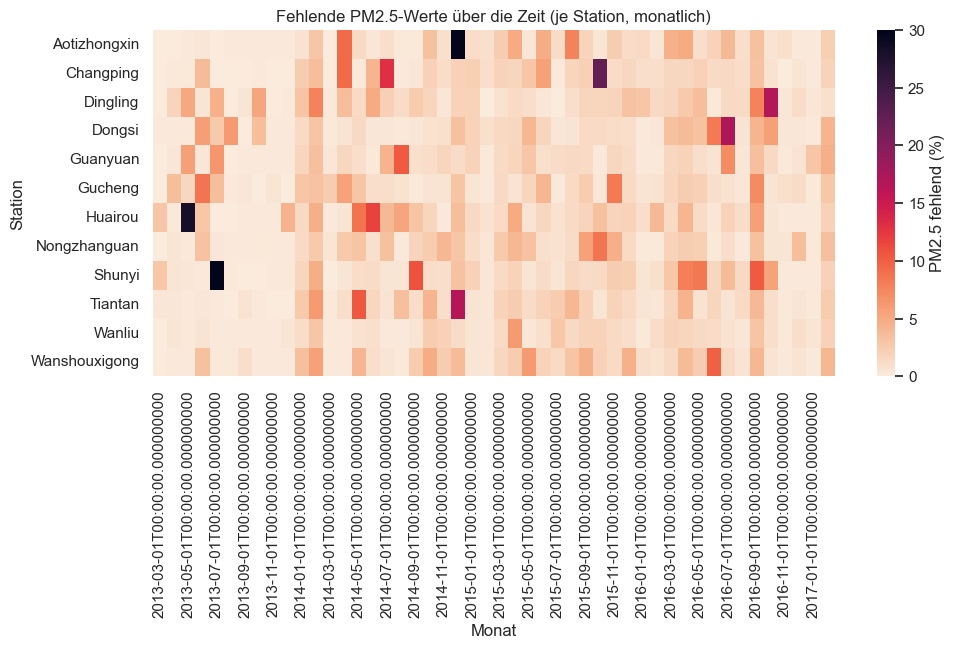

In [6]:
piv = (df.assign(ym=df.datetime.dt.to_period("M").dt.to_timestamp())
         .groupby(["station", "ym"])["PM2.5"]
         .apply(lambda s: s.isna().mean()*100).unstack(0))
plt.figure(figsize=(11, 4.5))
sns.heatmap(piv.T, cmap="rocket_r", vmax=30, cbar_kws={"label": "PM2.5 fehlend (%)"})
plt.title("Fehlende PM2.5-Werte über die Zeit (je Station, monatlich)")
plt.xlabel("Monat"); plt.ylabel("Station"); plt.show()

Pro Station fehlen die PM2.5-Werte so:

In [7]:
df.groupby('station')['PM2.5'].apply(lambda s: f"{s.isna().sum()} ({s.isna().mean()*100:.1f}%)")

station
Aotizhongxin     925 (2.6%)
Changping        774 (2.2%)
Dingling         779 (2.2%)
Dongsi           750 (2.1%)
Guanyuan         616 (1.8%)
Gucheng          646 (1.8%)
Huairou          953 (2.7%)
Nongzhanguan     628 (1.8%)
Shunyi           913 (2.6%)
Tiantan          677 (1.9%)
Wanliu           382 (1.1%)
Wanshouxigong    696 (2.0%)
Name: PM2.5, dtype: object

## 4. Verteilung der Werte — *wie sehen die Daten aus?*

Wie sind die PM2.5-Werte verteilt? Statistische Kennzahlen zuerst:

In [8]:
df['PM2.5'].describe()

count    412029.000000
mean         79.793428
std          80.822391
min           2.000000
25%          20.000000
50%          55.000000
75%         111.000000
max         999.000000
Name: PM2.5, dtype: float64

Auffällig: **Mittelwert (~80) > Median (55)** und Maximum **999** — die Verteilung ist stark **rechtsschief** 
mit seltenen, sehr hohen Smog-Spitzen. Das sieht man im Histogramm deutlich:

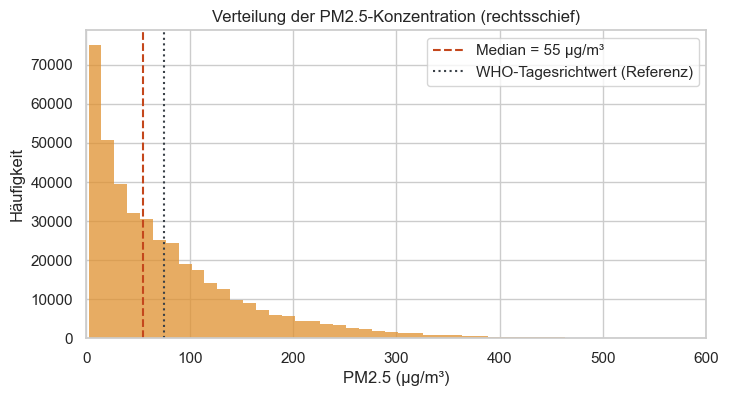

In [9]:
plt.figure(figsize=(8, 4))
sns.histplot(df["PM2.5"].dropna(), bins=80, color="#E0912F", edgecolor="none")
plt.axvline(df["PM2.5"].median(), color="#C4471C", ls="--", lw=1.5,
            label=f"Median = {df['PM2.5'].median():.0f} µg/m³")
plt.axvline(75, color="#3A4148", ls=":", lw=1.5, label="WHO-Tagesrichtwert (Referenz)")
plt.xlim(0, 600); plt.xlabel("PM2.5 (µg/m³)"); plt.ylabel("Häufigkeit")
plt.title("Verteilung der PM2.5-Konzentration (rechtsschief)"); plt.legend(); plt.show()

Und alle Schadstoffe im Vergleich (log-Skala, weil die Wertebereiche sehr unterschiedlich sind):

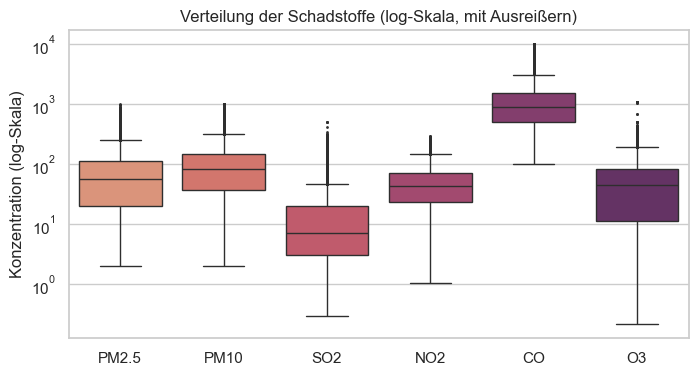

In [10]:
plt.figure(figsize=(8, 4))
sns.boxplot(data=df[pollutants], palette="flare", fliersize=1)
plt.yscale("log"); plt.ylabel("Konzentration (log-Skala)")
plt.title("Verteilung der Schadstoffe (log-Skala, mit Ausreißern)"); plt.show()

## 5. Zeitliche Muster — *Trend, Saison, Tagesgang*

PM2.5 ist eine Zeitreihe. Für Prophet & Co. sind wiederkehrende Muster zentral. 
Zuerst das **Monatsmittel** über die gesamten 4 Jahre:

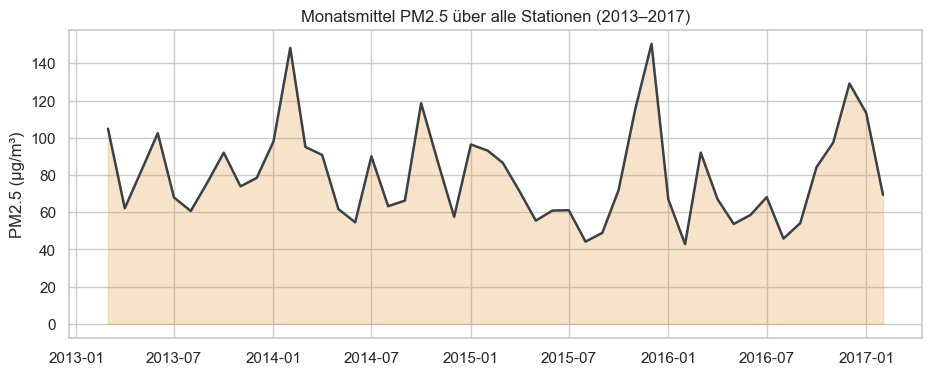

In [11]:
m = df.set_index("datetime")["PM2.5"].resample("MS").mean()
plt.figure(figsize=(11, 4))
plt.plot(m.index, m.values, color="#3A4148", lw=1.8)
plt.fill_between(m.index, m.values, color="#E0912F", alpha=0.25)
plt.ylabel("PM2.5 (µg/m³)")
plt.title("Monatsmittel PM2.5 über alle Stationen (2013–2017)"); plt.show()

Deutlich sichtbar: **Winter viel höher als Sommer** (Heizperiode). 
Diese Saisonalität sehen wir noch klarer, wenn wir über Monat und Stunde mitteln:

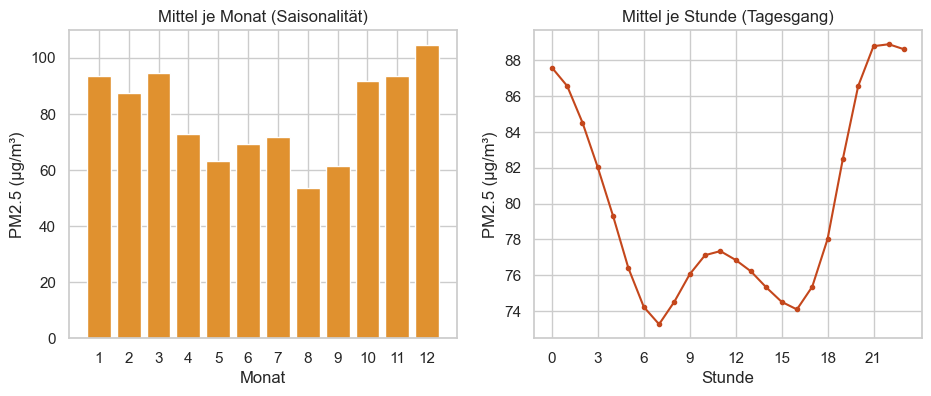

In [12]:
fig, ax = plt.subplots(1, 2, figsize=(11, 4))
mon = df.groupby("month")["PM2.5"].mean()
ax[0].bar(mon.index, mon.values, color="#E0912F")
ax[0].set_title("Mittel je Monat (Saisonalität)"); ax[0].set_xlabel("Monat")
ax[0].set_ylabel("PM2.5 (µg/m³)"); ax[0].set_xticks(range(1, 13))
hr = df.groupby("hour")["PM2.5"].mean()
ax[1].plot(hr.index, hr.values, color="#C4471C", marker="o", ms=3)
ax[1].set_title("Mittel je Stunde (Tagesgang)"); ax[1].set_xlabel("Stunde")
ax[1].set_ylabel("PM2.5 (µg/m³)"); ax[1].set_xticks(range(0, 24, 3)); plt.show()

## 6. Vergleich der Messstationen

Unterscheiden sich die 12 Stationen? (relevant, weil wir Multi-Site-Daten haben)

C:\Users\kaiws\AppData\Local\Temp\ipykernel_72420\1705097416.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="station", y="PM2.5", order=order, palette="flare", fliersize=0.5)


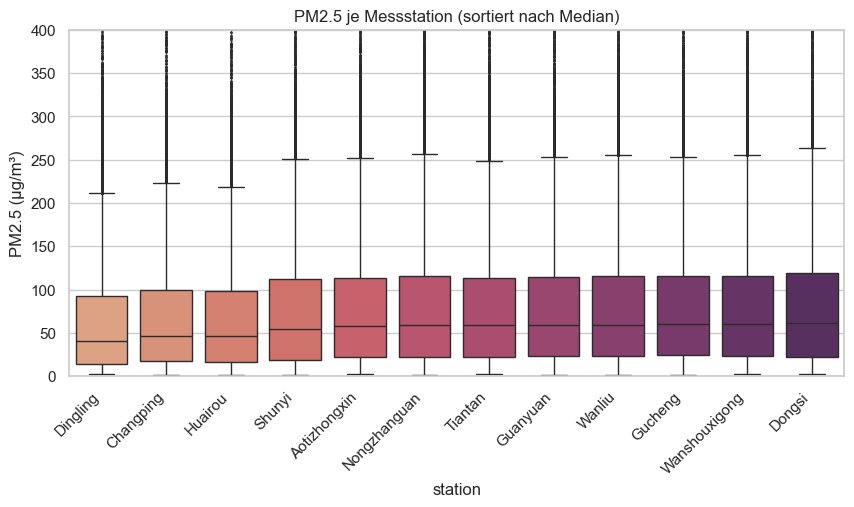

In [13]:
plt.figure(figsize=(10, 4.5))
order = df.groupby("station")["PM2.5"].median().sort_values().index
sns.boxplot(data=df, x="station", y="PM2.5", order=order, palette="flare", fliersize=0.5)
plt.ylim(0, 400); plt.xticks(rotation=45, ha="right"); plt.ylabel("PM2.5 (µg/m³)")
plt.title("PM2.5 je Messstation (sortiert nach Median)"); plt.show()

Die Stationen liegen erstaunlich nah beieinander — Beijing-weiter Smog trifft alle ähnlich, 
mit leicht niedrigeren Werten an den Rand-/Bergstationen (z. B. Dingling).

## 7. Zusammenhänge — Korrelationen

Welche Variablen hängen zusammen? Das hilft später bei der Auswahl **exogener Regressoren** für Prophet.

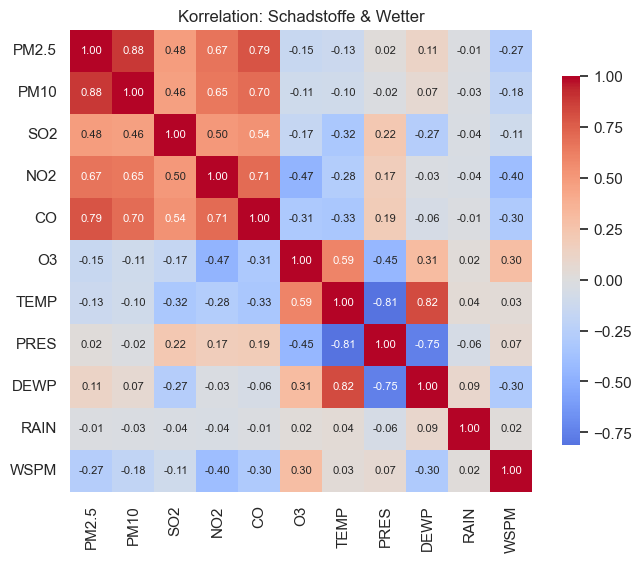

In [14]:
plt.figure(figsize=(7.5, 6))
corr = df[pollutants + meteo].corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, square=True,
            cbar_kws={"shrink": .8}, annot_kws={"size": 8})
plt.title("Korrelation: Schadstoffe & Wetter"); plt.show()

PM2.5 korreliert stark mit **PM10, CO und NO2** (gemeinsame Quellen) und **negativ mit Wind (WSPM)** 
— Wind bläst den Smog weg. Das macht Wetterdaten zu sinnvollen Zusatz-Features.

### Windrichtung
Verstärkt eine bestimmte Windrichtung den Smog?

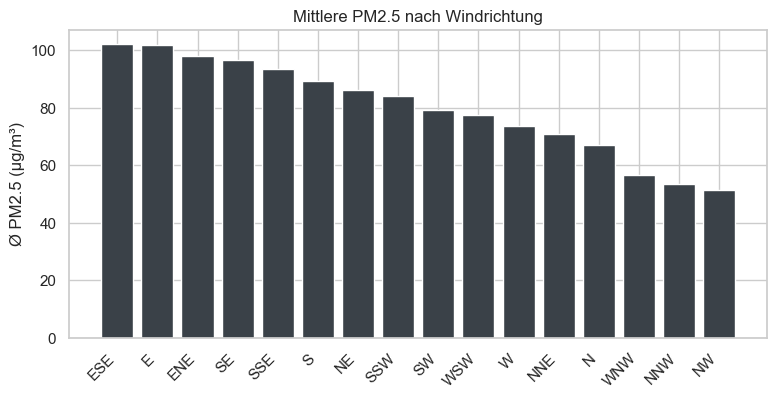

In [15]:
wd = df.groupby("wd")["PM2.5"].mean().sort_values(ascending=False)
plt.figure(figsize=(9, 4))
plt.bar(wd.index, wd.values, color="#3A4148")
plt.ylabel("Ø PM2.5 (µg/m³)"); plt.title("Mittlere PM2.5 nach Windrichtung")
plt.xticks(rotation=45, ha="right"); plt.show()

## 8. Feiertags-Effekt: Chinesisches Neujahr — Feuerwerk & Feinstaub

Zum chinesischen Neujahrsfest (Frühlingsfest) wird traditionell **um Mitternacht massiv Feuerwerk gezündet** — eine direkte, vom Wetter unabhängige PM2.5-Quelle. Das Fest folgt dem Mondkalender und wandert deshalb zwischen Ende Januar und Ende Februar. In unserem Datenzeitraum liegen vier Neujahrsfeste:

| Jahr | Neujahrstag |
|---|---|
| 2014 | 31. Januar |
| 2015 | 19. Februar |
| 2016 | 8. Februar |
| 2017 | 28. Januar |

Wir zeigen für jedes Jahr das **Stundenmittel über alle 12 Stationen** in einem Fenster von **±3 Tagen** um Mitternacht des Neujahrstags. Die gestrichelte Linie markiert Mitternacht (Feuerwerks-Höhepunkt), das schattierte Band die ±6 Stunden darum.

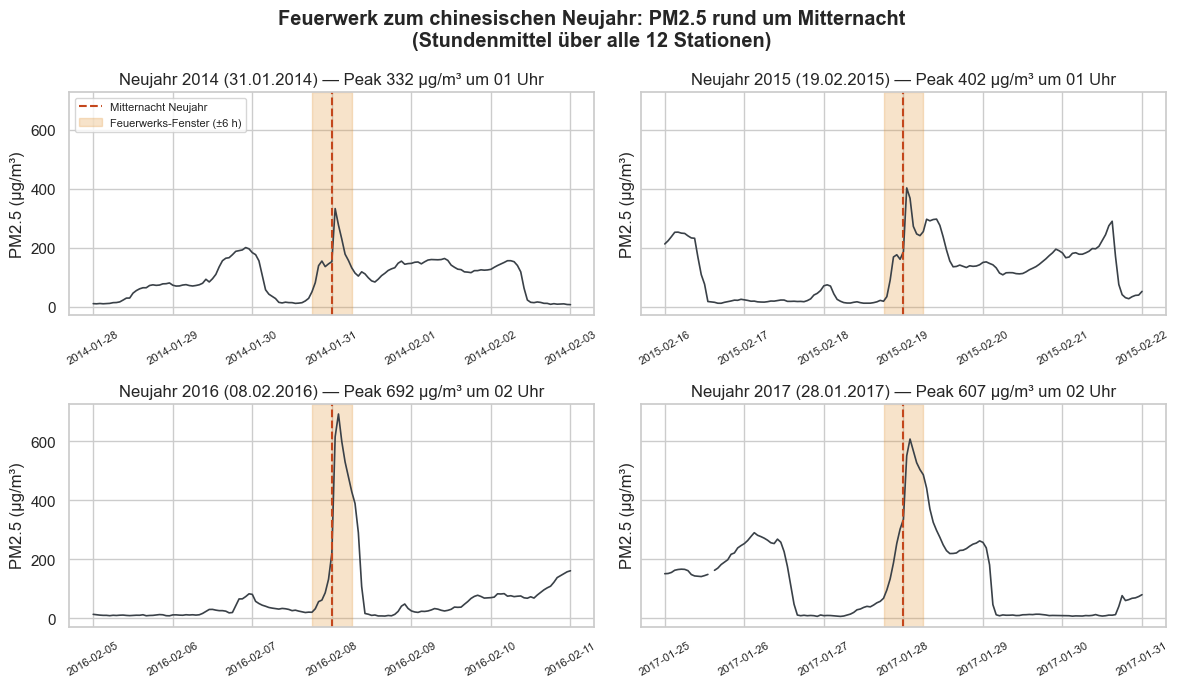

 Jahr Neujahrstag  Peak (µg/m³) Peak-Uhrzeit  Ø ±3 Tage  Faktor Peak/Umgebung
 2014  31.01.2014           332        01:00         96                   3.5
 2015  19.02.2015           402        01:00        116                   3.5
 2016  08.02.2016           692        02:00         68                  10.2
 2017  28.01.2017           607        02:00        132                   4.6


In [16]:
# Chinesisches Neujahr im Datenzeitraum (00:00 Uhr = Beginn des Neujahrstags)
CNY = {2014: "2014-01-31", 2015: "2015-02-19", 2016: "2016-02-08", 2017: "2017-01-28"}

stadt = df.groupby("datetime")["PM2.5"].mean()   # Stundenmittel ueber alle 12 Stationen

fig, axes = plt.subplots(2, 2, figsize=(12, 7), sharey=True)
kennzahlen = []
for ax, (jahr, tag) in zip(axes.ravel(), CNY.items()):
    t0 = pd.Timestamp(tag)                                     # Mitternacht = Feuerwerks-Hoehepunkt
    w = stadt.loc[t0 - pd.Timedelta(days=3): t0 + pd.Timedelta(days=3)]
    fest = w.loc[t0 - pd.Timedelta(hours=6): t0 + pd.Timedelta(hours=6)]

    ax.plot(w.index, w.values, color="#3A4148", lw=1.2)
    ax.axvline(t0, color="#C4471C", ls="--", lw=1.5, label="Mitternacht Neujahr")
    ax.axvspan(t0 - pd.Timedelta(hours=6), t0 + pd.Timedelta(hours=6),
               color="#E0912F", alpha=0.25, label="Feuerwerks-Fenster (±6 h)")
    ax.set_title(f"Neujahr {jahr} ({t0:%d.%m.%Y}) — Peak {fest.max():.0f} µg/m³ um {fest.idxmax():%H} Uhr")
    ax.set_ylabel("PM2.5 (µg/m³)")
    ax.tick_params(axis="x", rotation=30, labelsize=8)

    kennzahlen.append({"Jahr": jahr, "Neujahrstag": f"{t0:%d.%m.%Y}",
                       "Peak (µg/m³)": round(fest.max()), "Peak-Uhrzeit": f"{fest.idxmax():%H:%M}",
                       "Ø ±3 Tage": round(w.mean()),
                       "Faktor Peak/Umgebung": round(fest.max() / w.mean(), 1)})

axes[0, 0].legend(loc="upper left", fontsize=8)
plt.suptitle("Feuerwerk zum chinesischen Neujahr: PM2.5 rund um Mitternacht\n(Stundenmittel über alle 12 Stationen)",
             fontweight="bold")
plt.tight_layout(); plt.show()

print(pd.DataFrame(kennzahlen).to_string(index=False))

**Beobachtung:** In allen vier Jahren schießt PM2.5 **in den ersten ein bis zwei Stunden des Neujahrstags** steil nach oben — 2016 auf fast **700 µg/m³**, das rund **Zehnfache** des Umgebungsniveaus der Woche. Der Effekt ist kurz (wenige Stunden bis der Wind den Feuerwerksstaub verdünnt), aber kräftig — und er ist **vorhersagbar terminiert**, denn das Datum steht durch den Mondkalender fest. Ein klassischer **Kalender-Effekt**, den kein Wetter-Regressor erklären kann.

**Konsequenz für die Modellierung (Kapitel 04):** Genau solche Ereignisse kann Prophet über `add_country_holidays("CN")` als Feiertags-Features lernen — der Vergleichslauf „+ Feiertage (CN)“ prüft, ob sich das in den Fehlermaßen auszahlt.

## 10. PM2.5 im Zeitverlauf mit Luftgüte-Einstufung (China-AQI)

Monatsmittel des PM2.5 (Stadt-Mittel über alle 12 Stationen) über die vier Jahre, hinterlegt mit den offiziellen **chinesischen Luftgüte-Klassen** (AQI-Standard **HJ 633-2012**, PM2.5 als 24-h-Mittel). Farbskala **grün (unbedenklich)** bis **dunkelrot (Warnstufe)**:

| PM2.5 (µg/m³) | Chinesische Klasse | Deutsche Bezeichnung |
|---|---|---|
| 0–35 | 优 (Excellent) | Sehr gut – unbedenklich |
| 35–75 | 良 (Good) | Gut |
| 75–115 | 轻度污染 | Leicht verschmutzt |
| 115–150 | 中度污染 | Mäßig verschmutzt |
| 150–250 | 重度污染 | Stark verschmutzt |
| 250–350 (bis 500) | 严重污染 | Sehr stark – Warnstufe |

> Zum Vergleich: WHO-Jahresrichtwert (2021) = **5 µg/m³**, chinesisches Jahresziel = **35 µg/m³**. Beijing liegt im Monatsmittel fast durchgehend in „leicht" bis „stark verschmutzt", mit klaren Winter-Spitzen. Die Farbbänder entsprechen der **Tages**-AQI-Skala und dienen hier als Gesundheits-Orientierung.

**Vergleich der Jahres-Grenzwerte:** Chinas Jahreslimit (35 µg/m³) ist damit **um 40 % höher als das aktuelle EU-Limit (25 µg/m³)** und **3,5-fach über dem Wert, der in der EU ab 2030 gilt (10 µg/m³)**. Die gestrichelten Linien in der Grafik zeigen zum Vergleich den WHO-Richtwert (5), das EU-Ziel ab 2030 (10) und das aktuelle EU-Jahreslimit (25) — Beijing liegt im Monatsmittel durchgehend weit darüber.

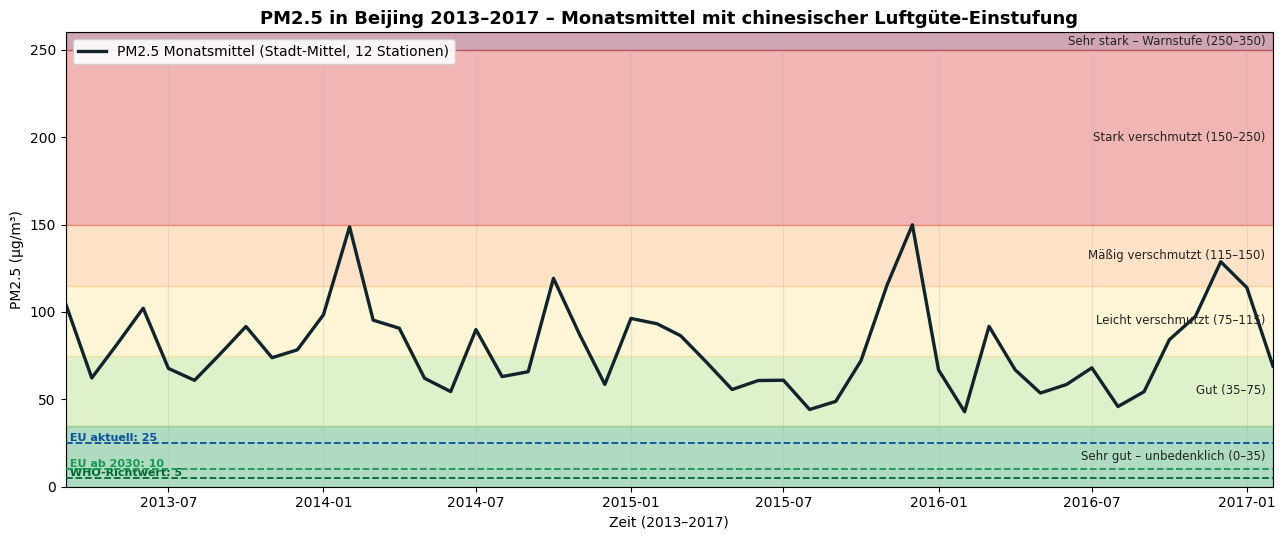

Zeitraum: 2013-03-01 bis 2017-02-01
Monatsmittel PM2.5: min 43, max 150, Mittel 80 µg/m³
WHO-Jahresrichtwert (2021): 5 µg/m³  |  China-Jahreslimit: 35  |  EU aktuell: 25  |  EU ab 2030: 10 µg/m³


In [1]:
# === PM2.5 im Zeitverlauf (2013–2017) mit chinesischer Luftgüte-Einstufung ===
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

RAW = Path('../data/PRSA_Data_20130301-20170228')
teile = [pd.read_csv(f, usecols=['year', 'month', 'day', 'hour', 'PM2.5'])
         for f in sorted(RAW.glob('PRSA_Data_*_20130301-20170228.csv'))]
roh = pd.concat(teile, ignore_index=True)
roh['ds'] = pd.to_datetime(roh[['year', 'month', 'day', 'hour']])
stadt = roh.groupby('ds')['PM2.5'].mean()          # Stadt-Mittel je Stunde (12 Stationen)
monat = stadt.resample('MS').mean()                # Monatsmittel

# China-AQI PM2.5 (24-h), HJ 633-2012: (unten, oben, Farbe, deutsche Bezeichnung)
KATEGORIEN = [
    (0,   35,  '#1a9850', 'Sehr gut – unbedenklich (0–35)'),
    (35,  75,  '#a6d96a', 'Gut (35–75)'),
    (75,  115, '#fee08b', 'Leicht verschmutzt (75–115)'),
    (115, 150, '#fdae61', 'Mäßig verschmutzt (115–150)'),
    (150, 250, '#d73027', 'Stark verschmutzt (150–250)'),
    (250, 350, '#7a0026', 'Sehr stark – Warnstufe (250–350)'),
]
YMAX = 260
fig, ax = plt.subplots(figsize=(13, 5.5))
for lo, hi, farbe, label in KATEGORIEN:
    ax.axhspan(lo, min(hi, YMAX), color=farbe, alpha=0.35, zorder=0)
    if lo < YMAX:
        ax.text(monat.index.max(), (lo + min(hi, YMAX)) / 2, label + '  ',
                ha='right', va='center', fontsize=8.5, color='#222222')
ax.plot(monat.index, monat.values, color='#10242b', lw=2.4,
        label='PM2.5 Monatsmittel (Stadt-Mittel, 12 Stationen)')

# Referenzlinien: Grenzwerte im Vergleich (gestrichelt)
for wert, farbe, txt in [(5, '#006837', 'WHO-Richtwert: 5'),
                         (10, '#1a9850', 'EU ab 2030: 10'),
                         (25, '#08519c', 'EU aktuell: 25')]:
    ax.axhline(wert, color=farbe, ls='--', lw=1.3, zorder=3)
    ax.text(monat.index.min(), wert, f' {txt}', va='bottom', ha='left',
            fontsize=8, color=farbe, fontweight='bold')
ax.set_xlim(monat.index.min(), monat.index.max())
ax.set_ylim(0, YMAX)
ax.set_ylabel('PM2.5 (µg/m³)'); ax.set_xlabel('Zeit (2013–2017)')
ax.set_title('PM2.5 in Beijing 2013–2017 – Monatsmittel mit chinesischer Luftgüte-Einstufung',
             fontsize=13, fontweight='bold')
ax.legend(loc='upper left', framealpha=0.9); ax.grid(axis='x', alpha=0.3)
plt.tight_layout(); plt.show()

print('Zeitraum:', monat.index.min().date(), 'bis', monat.index.max().date())
print(f'Monatsmittel PM2.5: min {monat.min():.0f}, max {monat.max():.0f}, Mittel {monat.mean():.0f} µg/m³')
print('WHO-Jahresrichtwert (2021): 5 µg/m³  |  China-Jahreslimit: 35  |  EU aktuell: 25  |  EU ab 2030: 10 µg/m³')

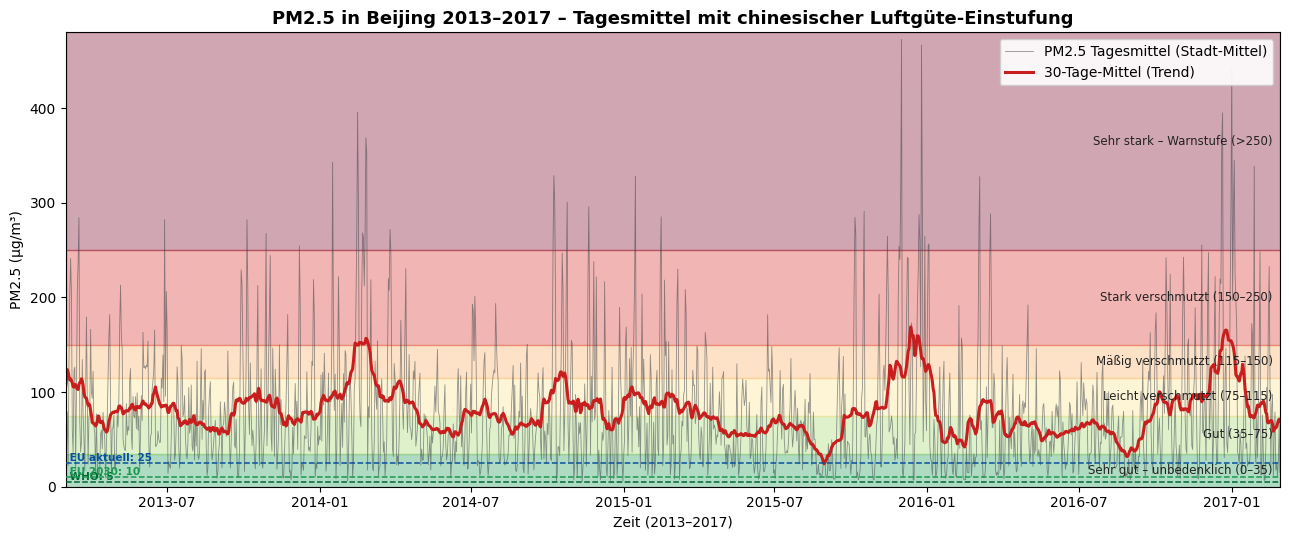

Tagesmittel PM2.5: min 5, max 473, Mittel 80 µg/m³
Tage > 150 (stark): 12.1 %  |  Tage > 250 (Warnstufe): 3.2 %


In [1]:
# === PM2.5 mit TAGESWERTEN + chinesischer Luftgüte-Einstufung ===
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

RAW = Path('../data/PRSA_Data_20130301-20170228')
teile = [pd.read_csv(f, usecols=['year', 'month', 'day', 'hour', 'PM2.5'])
         for f in sorted(RAW.glob('PRSA_Data_*_20130301-20170228.csv'))]
roh = pd.concat(teile, ignore_index=True)
roh['ds'] = pd.to_datetime(roh[['year', 'month', 'day', 'hour']])
stadt = roh.groupby('ds')['PM2.5'].mean()          # Stadt-Mittel je Stunde
tag   = stadt.resample('D').mean()                 # Tagesmittel
tag30 = tag.rolling(30, center=True, min_periods=10).mean()   # 30-Tage-Trend

KATEGORIEN = [
    (0,   35,  '#1a9850', 'Sehr gut – unbedenklich (0–35)'),
    (35,  75,  '#a6d96a', 'Gut (35–75)'),
    (75,  115, '#fee08b', 'Leicht verschmutzt (75–115)'),
    (115, 150, '#fdae61', 'Mäßig verschmutzt (115–150)'),
    (150, 250, '#d73027', 'Stark verschmutzt (150–250)'),
    (250, 500, '#7a0026', 'Sehr stark – Warnstufe (>250)'),
]
YMAX = 480
fig, ax = plt.subplots(figsize=(13, 5.5))
for lo, hi, farbe, label in KATEGORIEN:
    ax.axhspan(lo, min(hi, YMAX), color=farbe, alpha=0.35, zorder=0)
    if lo < YMAX:
        ax.text(tag.index.max(), (lo + min(hi, YMAX)) / 2, label + '  ',
                ha='right', va='center', fontsize=8.5, color='#222222')
ax.plot(tag.index, tag.values, color='#3a4148', lw=0.6, alpha=0.55, label='PM2.5 Tagesmittel (Stadt-Mittel)')
ax.plot(tag30.index, tag30.values, color='#c81e1e', lw=2.2, label='30-Tage-Mittel (Trend)')
for wert, farbe, txt in [(5, '#006837', 'WHO: 5'), (10, '#1a9850', 'EU 2030: 10'), (25, '#08519c', 'EU aktuell: 25')]:
    ax.axhline(wert, color=farbe, ls='--', lw=1.1, zorder=3)
    ax.text(tag.index.min(), wert, f' {txt}', va='bottom', ha='left', fontsize=7.5, color=farbe, fontweight='bold')
ax.set_xlim(tag.index.min(), tag.index.max()); ax.set_ylim(0, YMAX)
ax.set_ylabel('PM2.5 (µg/m³)'); ax.set_xlabel('Zeit (2013–2017)')
ax.set_title('PM2.5 in Beijing 2013–2017 – Tagesmittel mit chinesischer Luftgüte-Einstufung',
             fontsize=13, fontweight='bold')
ax.legend(loc='upper right', framealpha=0.9)
plt.tight_layout(); plt.show()

print(f'Tagesmittel PM2.5: min {tag.min():.0f}, max {tag.max():.0f}, Mittel {tag.mean():.0f} µg/m³')
print(f'Tage > 150 (stark): {(tag>150).mean()*100:.1f} %  |  Tage > 250 (Warnstufe): {(tag>250).mean()*100:.1f} %')

## 9. Zusammenfassung — *was ist da, was fehlt?*

**Was ist da (Stärken):**
- Vollständige, saubere **stündliche Zeitreihe** über 4 Jahre × 12 Stationen (**420.768 Zeilen**).
- Zielgröße **PM2.5** plus 5 weitere Schadstoffe und 5 Wettervariablen als potenzielle Regressoren.
- Klare **Saisonalität** (Winter-Peak) und **Tagesgang** — ideal für Prophet/Chronos/PatchTST.
- Klarer **Feiertags-Effekt:** Feuerwerk zum chinesischen Neujahr lässt PM2.5 kurzzeitig auf das 3- bis 10-fache springen (Abschnitt 8) → Argument für Feiertags-Features in der Modellierung.
- Wetterdaten praktisch lückenlos (< 0,1 % fehlend).

**Was fehlt / worauf achten (Schwächen & To-dos für Phase 3):**
- **Fehlende Werte:** PM2.5 ~2 %, andere Schadstoffe bis ~5 % (CO). → Imputation nötig (z. B. zeitliche Interpolation).
- Lücken teils als **zusammenhängende Blöcke** (siehe Heatmap) → einfache Interpolation reicht dort evtl. nicht.
- **Starke Rechtsschiefe & Ausreißer** (Max 999) → Log-/Transformation oder robuste Behandlung prüfen.
- **Kategoriale Windrichtung `wd`** muss noch kodiert werden (z. B. One-Hot oder in Grad).
- Für Prophet: chronologischer, **leakage-freier** Train/Test-Split (kein Zufalls-Split!).

> **Nächster Schritt (CRISP-DM Phase 3 – Datenaufbereitung):** fehlende Werte behandeln, Features aufbereiten, Zeitreihe je Station modellfertig machen.